In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from google.colab.patches import cv2_imshow

In [2]:
!pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.9/8062.4 GB disk)


In [3]:
from IPython.display import Image as IPyImage

In [4]:
import glob
import os
from IPython.display import Image as IPyImage, display

#latest_folder = max(glob.glob(f'runs/detect/predict*/'), key=os.path.getmtime)
#for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
#    display(IPyImage(filename=img, width=600))
 #   print("\n")

# Extracting ROI and Getting Color

# Multi ROIS

In [5]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt


def person_detect(image, model_path, dataset="None"):
    """Draw bounding boxes on detected objects with color labels."""
    person_count = 0
    person_roi_dict = {}
    
    try:
        model = YOLO(model_path)
        
        results = model.predict(image)[0]

        if not results.boxes:
            print("No objects detected.")
            return image
        
        

        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf = float(box.conf.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            if x1 >= 0 and y1 >= 0 and x2 <= image.shape[1] and y2 <= image.shape[0] and x2 > x1 and y2 > y1:
                person_boxes = [(x1, y1, x2-x1, y2-y1)]
                person_roi_dict[person_count] = person_boxes
                person_count += 1

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
                label = f"({conf:.2f})"
                label_position = (x1, y1 - 10) if y1 > 20 else (x1, y1 + 20)
                cv2.putText(image, label, label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)
                    
            else:
                print(f"Invalid bounding box coordinates: {x1}, {y1}, {x2}, {y2} for image shape {image.shape}")
                continue
        return person_roi_dict, image

    except Exception as e:
        print(f"An error occurred: {e}")
        return None


In [6]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

def preprocess_image(image):
    """Enhance image before color detection by reducing lighting and adjusting contrast."""
    # Apply CLAHE to improve contrast
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    
    # Convert back to BGR
    enhanced_image = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    # Apply gamma correction
    gamma = 1.2
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(enhanced_image, table)

def get_color_from_hsv(helmet_roi):
    """Use histogram-based detection for the dominant color in HSV."""
    hsv = cv2.cvtColor(helmet_roi, cv2.COLOR_BGR2HSV)
    
    # Calculate histogram in HSV space
    hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256])
    hist_saturation = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    hist_value = cv2.calcHist([hsv], [2], None, [256], [0, 256])
    
    dominant_hue = np.argmax(hist_hue)
    dominant_saturation = np.argmax(hist_saturation)
    dominant_value = np.argmax(hist_value)

    return dominant_hue, dominant_saturation, dominant_value

# Updated HSV color ranges with increased tolerance
color_ranges_hsv = {
    "red": [(0, 100, 100), (10, 255, 255)],
    "yellow": [(20, 100, 100), (40, 255, 255)],
    "green": [(40, 100, 100), (80, 255, 255)],
    "blue": [(90, 100, 100), (150, 255, 255)],
    "orange": [(10, 100, 100), (25, 255, 255)],
    "white": [(0, 0, 180), (180, 20, 255)],  # Expanded white range
}

def get_color_name(hsv):
    """Match HSV value to the closest predefined color range."""
    h, s, v = hsv
    for name, (lower, upper) in color_ranges_hsv.items():
        lh, ls, lv = lower
        uh, us, uv = upper
        if lh <= h <= uh and ls <= s <= us and lv <= v <= uv:
            return name
    return "Unknown"

def helmet_crop(image, helmet_boxes):
    """Crop the image focusing on the middle part of the upper half of the bounding box."""
    helmet_images = []
    for (x, y, w, h) in helmet_boxes:
        # Define the middle part of the upper half
        mid_x1 = x + w // 4  # Start from 1/4th width
        mid_x2 = x + (3 * w) // 4  # End at 3/4th width
        mid_y1 = y  # Start from the top
        mid_y2 = y + h // 2  # End at half the height

        middle_upper_part = image[mid_y1:mid_y2, mid_x1:mid_x2]
        middle_upper_part = reduce_glare(middle_upper_part)
        helmet_images.append(middle_upper_part)

    return helmet_images


def draw_bounding_boxes_with_color_better(image, model_path, dataset="None"):
    """Draw bounding boxes on detected objects with color labels."""
    try:
        model = YOLO(model_path)
        
        results = model.predict(image, max_det=1)[0]

        #image = cv2.imread(image_path)
        
        #if image is None:
        #    raise FileNotFoundError(f"Image at path {image_path} could not be loaded.")

        if not results.boxes:
            print("No objects detected.")
            return image

        color_counts = defaultdict(int)

        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf = float(box.conf.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            if x1 >= 0 and y1 >= 0 and x2 <= image.shape[1] and y2 <= image.shape[0] and x2 > x1 and y2 > y1:
                helmet_boxes = [(x1, y1, x2-x1, y2-y1)]
                helmet_images = helmet_crop(image, helmet_boxes)

                for helmet_roi in helmet_images:
                    if helmet_roi.size == 0:
                        print("Empty helmet ROI. Skipping.")
                        continue

                    # Get the dominant color using histogram-based method
                    dominant_hue, dominant_saturation, dominant_value = get_color_from_hsv(helmet_roi)
                    color_name = get_color_name((dominant_hue, dominant_saturation, dominant_value))
                    color_counts[color_name] += 1

                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label = f"{color_name} ({conf:.2f})"
                    label_position = (x1, y1 - 10) if y1 > 20 else (x1, y1 + 20)
                    cv2.putText(image, label, label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 2)

                    print(f"Detected helmet color: {color_name} | Confidence: {conf:.2f}")
            else:
                print(f"Invalid bounding box coordinates: {x1}, {y1}, {x2}, {y2} for image shape {image.shape}")
                continue

        #cv2_imshow(image)
        #cv2.imwrite(dataset,image)
        
            
        return color_name, image

    except Exception as e:
        print(f"An error occurred: {e}")
        return "none", image

# Mobile Detect

In [7]:
import cv2
import numpy as np

def reduce_glare(image, threshold=220, blur_ksize=15):
    """
    Reduces glare from shiny surfaces (like helmets) in sunny conditions.
    
    Parameters:
    - image: input BGR image (np.ndarray)
    - threshold: brightness threshold to detect glare (0–255)
    - blur_ksize: blur kernel size to blend glare region
    
    Returns:
    - glare-reduced image
    """
    # Convert to grayscale to detect bright regions
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create glare mask (bright regions)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Optional: dilate mask to cover edges
    mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)

    # Inpaint glare region
    result = cv2.inpaint(image, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

    return result


In [8]:
import cv2
import numpy as np

def preprocess_image(image):
    """Enhance image before color detection by reducing lighting and adjusting contrast."""
    # Apply CLAHE to improve contrast
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    
    # Convert back to BGR
    enhanced_image = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    # Apply gamma correction
    gamma = 1.2
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(enhanced_image, table)

def helmet_crop(image, helmet_boxes):
    """Crop the image focusing on the middle part of the upper half of the bounding box."""
    helmet_images = []
    for (x, y, w, h) in helmet_boxes:
        # Define the middle part of the upper half
        mid_x1 = x + w // 4  # Start from 1/4th width
        mid_x2 = x + (3 * w) // 4  # End at 3/4th width
        mid_y1 = y  # Start from the top
        mid_y2 = y + h // 2  # End at half the height

        middle_upper_part = image[mid_y1:mid_y2, mid_x1:mid_x2]
        middle_upper_part = reduce_glare(middle_upper_part)
        helmet_images.append(middle_upper_part)

    return helmet_images




def draw_bounding_boxes_mobile(image_path, detect_hat_image, model_path, dataset="None"):
    """Draw bounding boxes on detected objects with color labels."""
    try:
        model = YOLO(model_path)
        results = model.predict(image_path)[0]

        count = 0
        
        image = detect_hat_image
        if image is None:
            raise FileNotFoundError(f"Image at path {image_path} could not be loaded.")

        if not results.boxes:
            print("No objects detected.")
            return count, image

        

        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf = float(box.conf.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            if x1 >= 0 and y1 >= 0 and x2 <= image.shape[1] and y2 <= image.shape[0] and x2 > x1 and y2 > y1:
                count += 1
                helmet_boxes = [(x1, y1, x2-x1, y2-y1)]
                helmet_images = helmet_crop(image, helmet_boxes)

                for helmet_roi in helmet_images:
                    if helmet_roi.size == 0:
                        print("Empty Mobile ROI. Skipping.")
                        continue

                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
                    #label = "Detected"
                    label = f"Detected ({conf:.2f})"
                    label_position = (x1, y1 - 10) if y1 > 20 else (x1, y1 + 20)
                    cv2.putText(image, label, label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)
            else:
                label = "Not Detected"
                label_position = (x1, y1 - 10) if y1 > 20 else (x1, y1 + 20)
                cv2.putText(image, label, label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)
                print(f"Invalid bounding box coordinates: {x1}, {y1}, {x2}, {y2} for image shape {image.shape}")
                return count , image
                

        #cv2_imshow(image)
        #cv2.imwrite(dataset,image)
        
            
        return count , image

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [9]:
def analyze_phone_usage_on_custom_image(original_image, display_image, model=None):
    import cv2
    import numpy as np
    from ultralytics import YOLO

    # Load model if not provided
    if model is None:
        model = YOLO("yolov8s-pose.pt")

    # Helper: load image if input is a path
    def load_image(img_input):
        if isinstance(img_input, str):
            img = cv2.imread(img_input)
            if img is None:
                raise ValueError(f"Failed to load image from path: {img_input}")
            return img
        elif isinstance(img_input, np.ndarray):
            return img_input.copy()
        else:
            raise TypeError("Input must be either a file path or a NumPy array.")

    # Load and preprocess images
    original_img = load_image(original_image)
    display_img = load_image(display_image)
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Pose estimation
    results = model(original_rgb)
    keypoints_tensor = results[0].keypoints.data
    keypoints = keypoints_tensor.cpu().numpy()

    if len(keypoints) == 0:
        return display_img, "No person detected."

    # Extract first person
    kps = keypoints[0]

    left_wrist = kps[9][:2]
    left_elbow = kps[7][:2]
    left_shoulder = kps[5][:2]

    right_wrist = kps[10][:2]
    right_elbow = kps[8][:2]
    right_shoulder = kps[6][:2]

    # Angle calculation
    def calculate_angle(a, b, c):
        a, b, c = np.array(a), np.array(b), np.array(c)
        ba = a - b
        bc = c - b
        cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
        return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

    left_angle = calculate_angle(left_wrist, left_elbow, left_shoulder)
    right_angle = calculate_angle(right_wrist, right_elbow, right_shoulder)

    if left_angle < 90 and right_angle < 90:
        message = "Likely using mobile phone (both hands raised)"
    elif left_angle < 90 or right_angle < 90:
        message = "Possibly using mobile phone (one hand raised)"
    else:
        message = "Unlikely using mobile phone"

    # Draw keypoints and lines
    kp_color = (0, 255, 0)
    line_color = (255, 0, 0)
    font_color = (0, 0, 255)

    def draw_kp(pt): cv2.circle(display_img, tuple(map(int, pt)), 5, kp_color, -1)
    def draw_line(p1, p2): cv2.line(display_img, tuple(map(int, p1)), tuple(map(int, p2)), line_color, 2)

    # Draw left arm
    draw_kp(left_wrist)
    draw_kp(left_elbow)
    draw_kp(left_shoulder)
    draw_line(left_wrist, left_elbow)
    draw_line(left_elbow, left_shoulder)

    # Draw right arm
    draw_kp(right_wrist)
    draw_kp(right_elbow)
    draw_kp(right_shoulder)
    draw_line(right_wrist, right_elbow)
    draw_line(right_elbow, right_shoulder)

    # Display message
    #cv2.putText(display_img, message, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, font_color, 2)

    return display_img, message


In [10]:
import cv2
import gc

def hardhat_mobile_detect(image_path, person_model_path, helmet_model_path, mobile_model_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Detect persons
    person_roi_dict, person_image = person_detect(image=image, model_path=person_model_path, dataset="None")

    # Process each detected person
    for rois in person_roi_dict.values():
        if not rois:
            continue
        x1, y1, width, height = rois[0]
        
        # Calculate bottom-right coordinates
        x2, y2 = x1 + width, y1 + height

        # Ensure coordinates are within bounds
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(image.shape[1], x2), min(image.shape[0], y2)

        # Extract and process the person's ROI
        person_roi = image[y1:y2, x1:x2].copy()
        
        color_name, helmet_detect = draw_bounding_boxes_with_color_better(person_roi, model_path=helmet_model_path, dataset="None")

        helmet_detect_copy = helmet_detect.copy()

        if color_name == "yellow":
            count, mobile_detect = draw_bounding_boxes_mobile(person_roi, helmet_detect_copy, model_path=mobile_model_path, dataset="None")

            if count!=0:
                #image[y1:y2, x1:x2] = mobile_detect
                mobile_angle_detect, message = analyze_phone_usage_on_custom_image(person_roi, mobile_detect, model=None)
                #message = "Yellow Helmet Detected"
                person_image[y1:y2, x1:x2] = mobile_angle_detect
            else:
                person_image[y1:y2, x1:x2] = helmet_detect
                message = "Yellow Helmet Detected | Mobile Phone not Detected"
        else:
            person_image[y1:y2, x1:x2] = helmet_detect
            message = "Non-Yellow Helmet Detected"
        
        

    # Display the result
    cv2_imshow(person_image)
    print(message)

In [11]:
person_model_path = "/kaggle/input/person-detec-roi/person_detect/best.pt"
helmet_model_path = "/kaggle/input/yolobestmodel/bestmodelyolo/best.pt"
mobile_model_path = "/kaggle/input/mobiledetect/mobile detect/best.pt"


0: 640x288 1 Persona, 54.0ms
Speed: 3.8ms preprocess, 54.0ms inference, 32.2ms postprocess per image at shape (1, 3, 640, 288)

0: 640x576 1 Hardhat, 49.7ms
Speed: 1.9ms preprocess, 49.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 576)
Detected helmet color: yellow | Confidence: 0.72

0: 640x576 1 0, 15.5ms
Speed: 1.9ms preprocess, 15.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 576)

0: 640x576 1 person, 28.5ms
Speed: 1.9ms preprocess, 28.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)


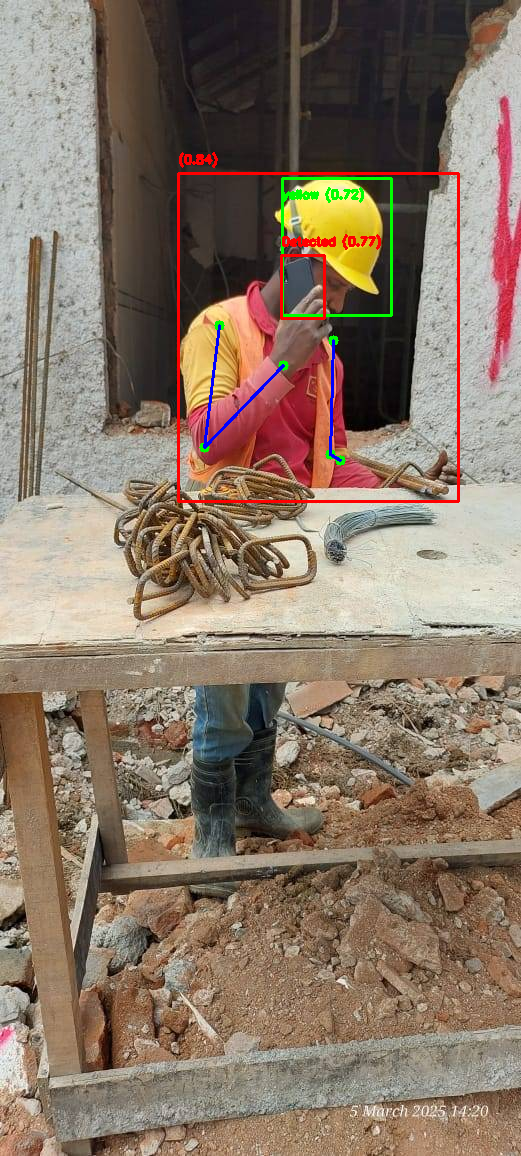

Possibly using mobile phone (one hand raised)


In [12]:
image_path_1 = "/kaggle/input/total-srilankanhelmetmobile/total_mobileandhelmetsrilanka/1741165662850.jpg"
hardhat_mobile_detect(image_path_1,person_model_path, helmet_model_path, mobile_model_path)


0: 640x288 1 Persona, 11.3ms
Speed: 1.5ms preprocess, 11.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 1 Hardhat, 11.1ms
Speed: 1.3ms preprocess, 11.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 288)
Detected helmet color: blue | Confidence: 0.61


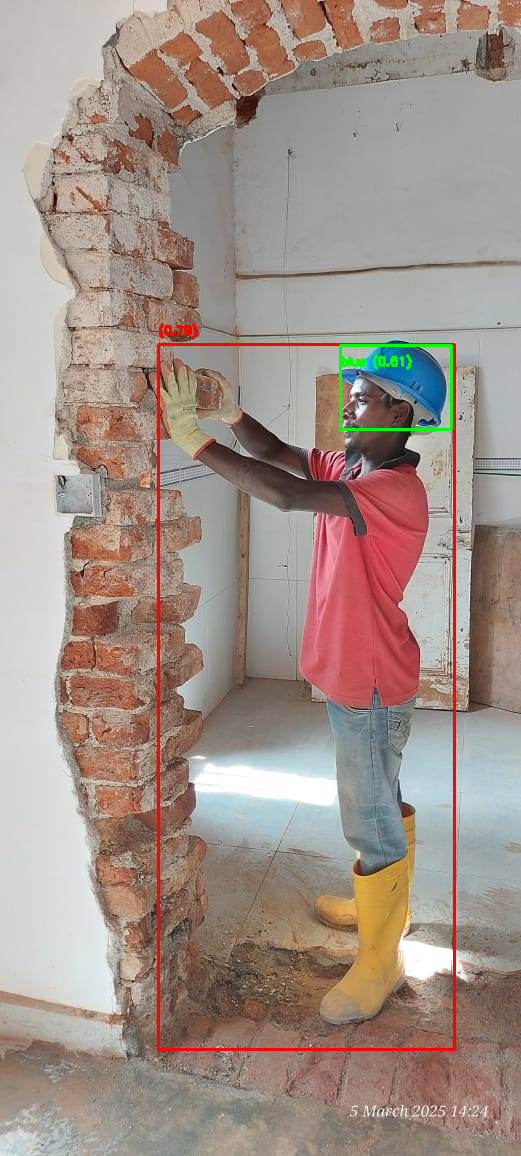

Non-Yellow Helmet Detected


In [13]:
image_path_3 = "/kaggle/input/total-srilankanhelmetmobile/total_mobileandhelmetsrilanka/1741165665034.jpg"
hardhat_mobile_detect(image_path_3,person_model_path, helmet_model_path, mobile_model_path)


0: 640x480 2 Personas, 54.0ms
Speed: 2.3ms preprocess, 54.0ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 480)

0: 640x256 1 Hardhat, 52.9ms
Speed: 1.2ms preprocess, 52.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 256)
Detected helmet color: yellow | Confidence: 0.73

0: 640x256 (no detections), 10.6ms
Speed: 1.2ms preprocess, 10.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 256)
No objects detected.

0: 640x224 1 Hardhat, 54.3ms
Speed: 1.2ms preprocess, 54.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 224)
Detected helmet color: yellow | Confidence: 0.82

0: 640x224 1 0, 10.2ms
Speed: 1.2ms preprocess, 10.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 224)

0: 640x224 1 person, 29.1ms
Speed: 1.3ms preprocess, 29.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 224)


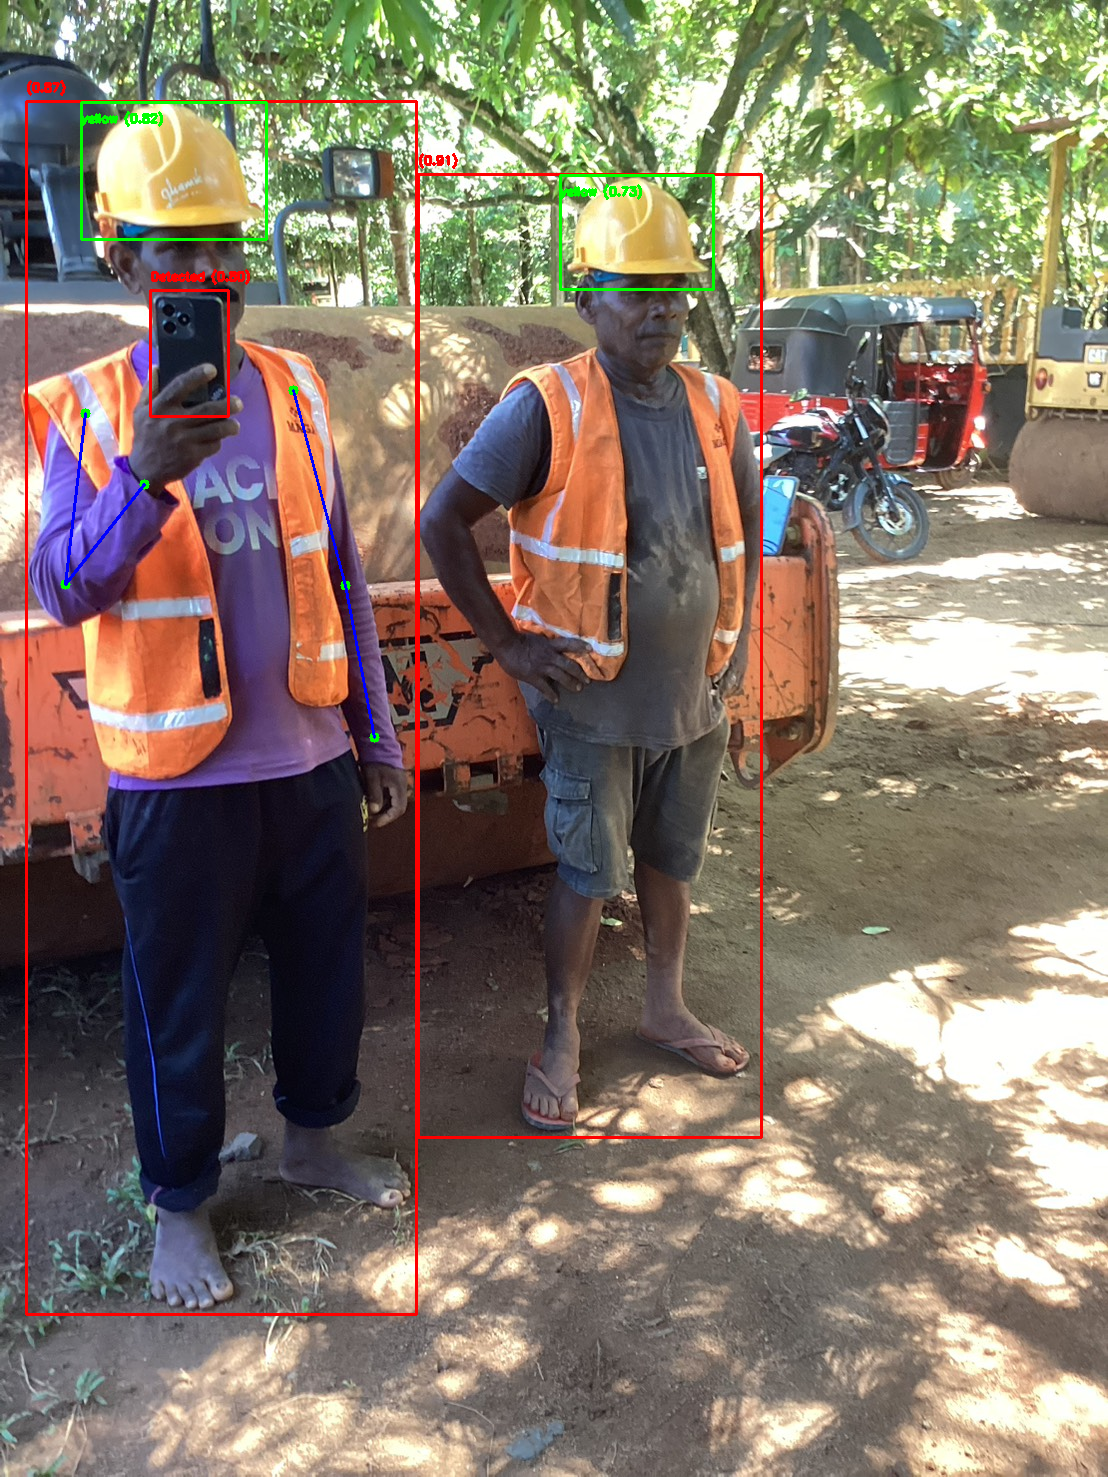

Possibly using mobile phone (one hand raised)


In [14]:
image_path_4 = "/kaggle/input/newphonedetectnew/1748922799568.jpg"
hardhat_mobile_detect(image_path_4,person_model_path, helmet_model_path, mobile_model_path)